In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M2-PJT_TXT


In [4]:
import sys
sys.path.append("src")

# packages

In [ ]:
from pathlib import Path
import pickle
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pymyproject.bcpd import analysis

# data

In [11]:
PATH = "./result/factor/scores.pkl"
with open(file=PATH, mode="rb") as f:
    scores = pickle.load(f)

In [12]:
FACTOR = 3
PATH = f"./result/bcpd/f{FACTOR}/"
folder = Path(PATH)

trace = dict()

for i, PATH in enumerate(folder.glob("*.nc")):
    with open(file=PATH, mode="rb") as f:
        trace[i+1] = az.from_netcdf(PATH)

# convergence diagnostics

## N_CPS==1

In [13]:
N_CPS = 1
data = trace[N_CPS]

In [14]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


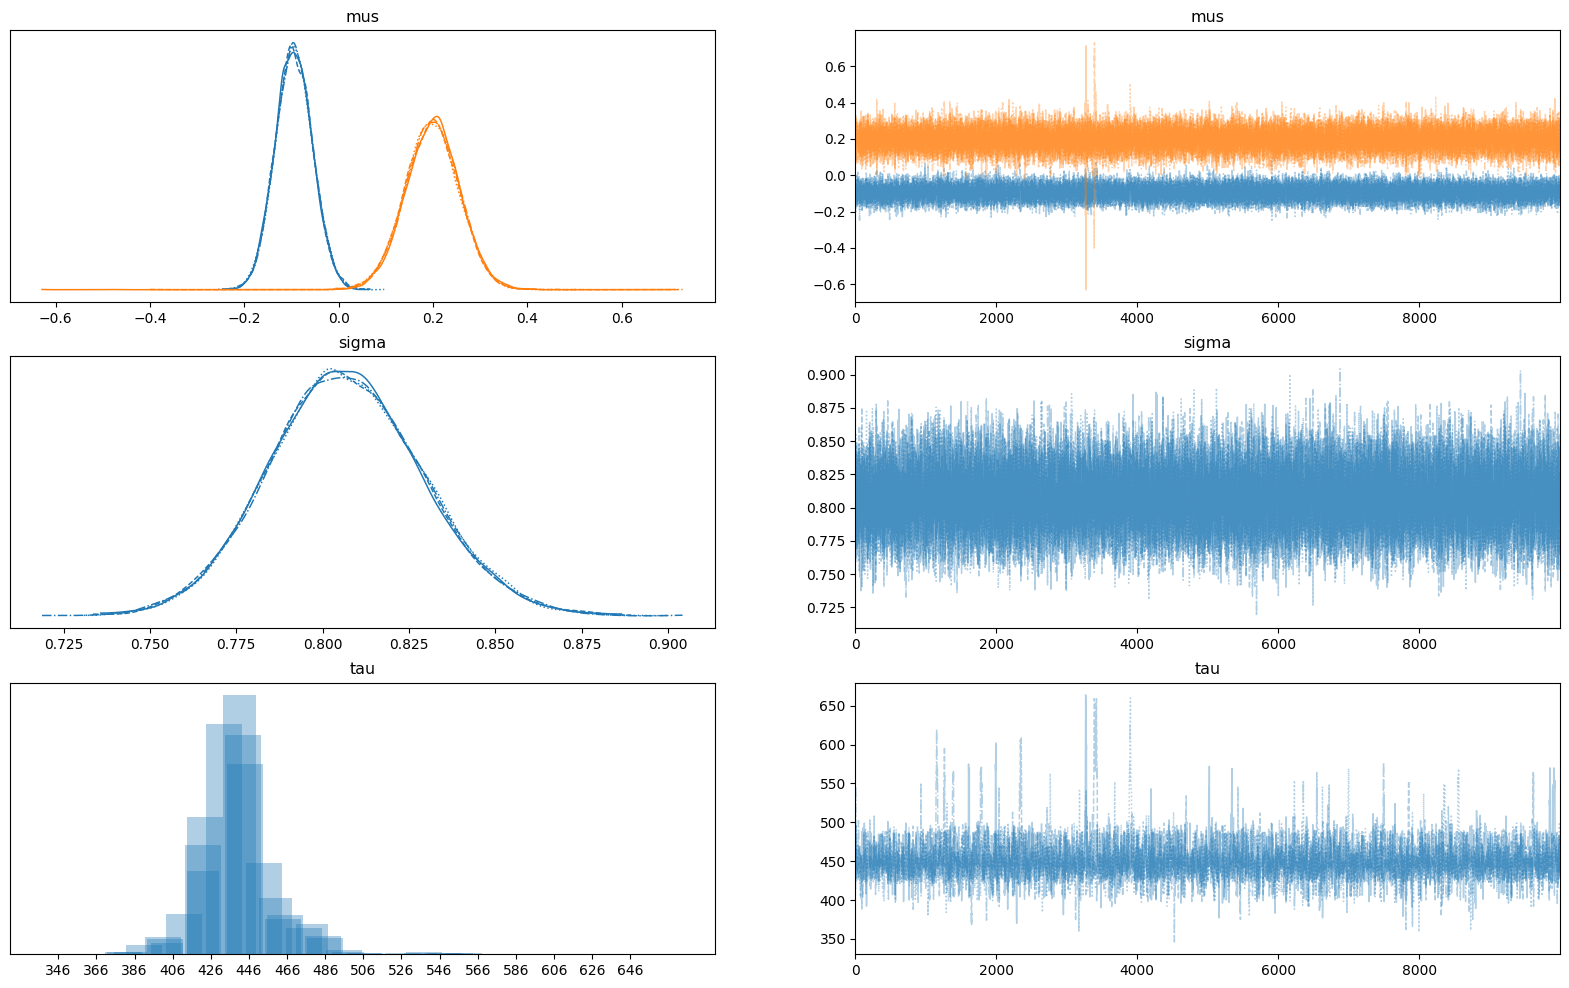

In [15]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==2

In [16]:
N_CPS = 2
data = trace[N_CPS]

In [17]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[0],0.045,0.110,-0.114,0.255,0.031,0.008,13.0,107.0,1.21
mus[1],-0.345,0.307,-1.149,-0.053,0.127,0.114,7.0,17.0,1.48
mus[2],0.173,0.074,0.028,0.301,0.023,0.011,12.0,21.0,1.23
tau[0],231.809,108.608,75.000,333.000,40.417,7.389,9.0,112.0,1.34
tau[1],426.386,43.524,337.000,459.000,17.965,13.431,9.0,17.0,1.35


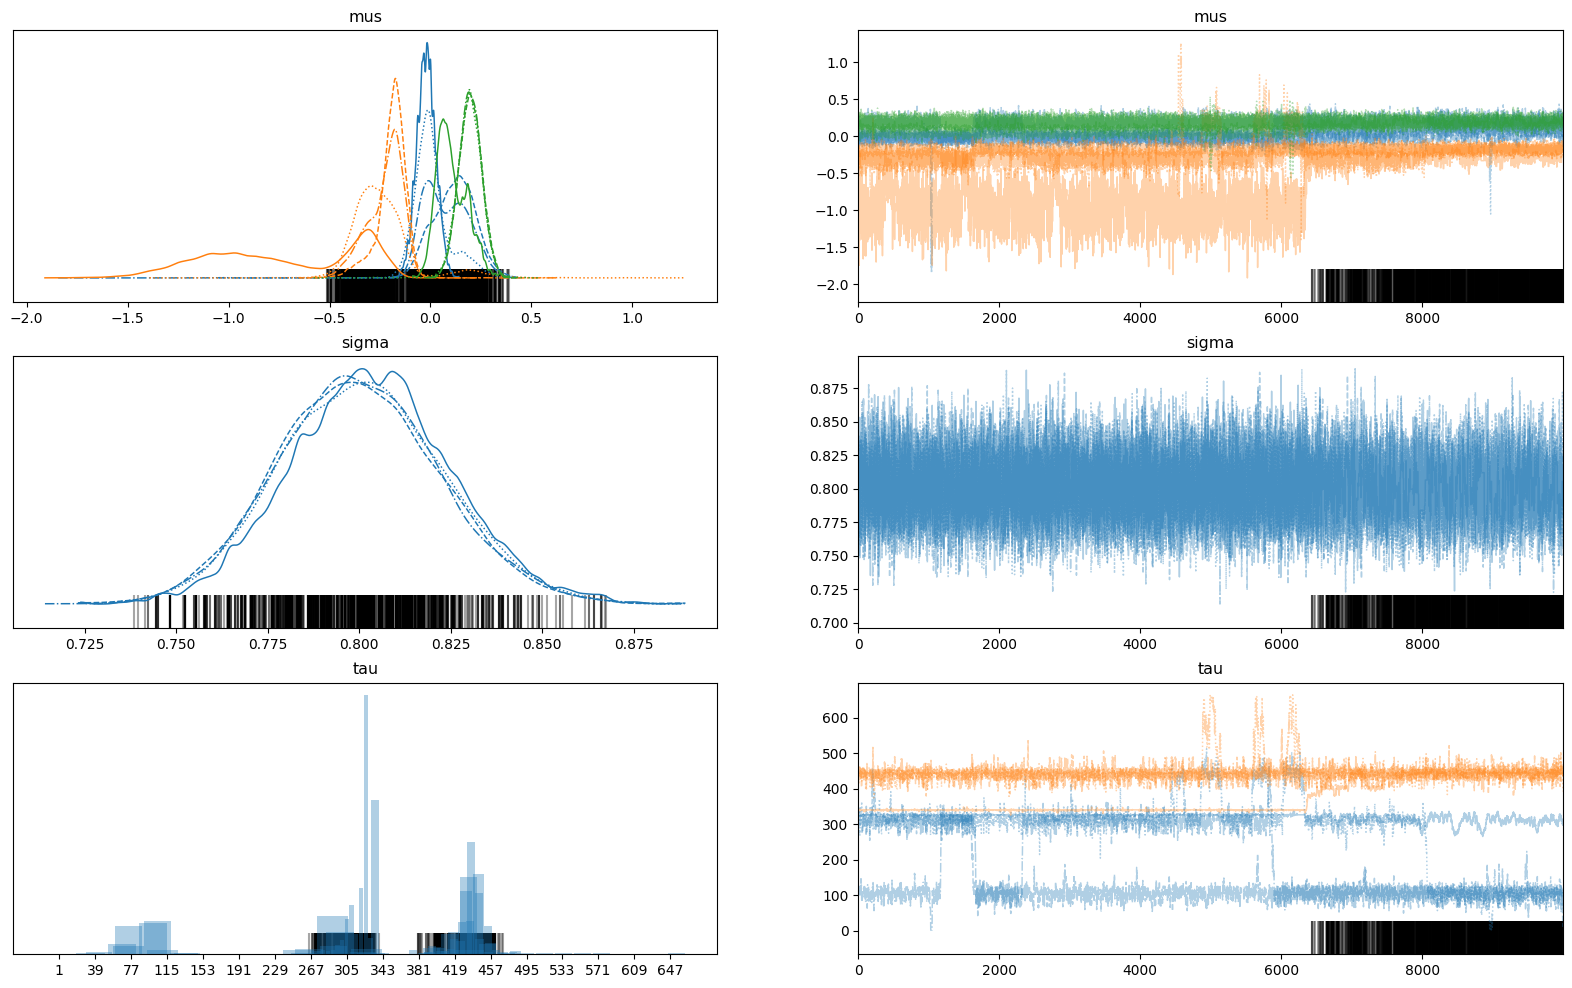

In [18]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==3

In [19]:
N_CPS = 3
data = trace[N_CPS]

In [20]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[1],0.900,0.281,0.422,1.448,0.010,0.016,1187.0,381.0,1.01
tau[1],271.551,7.585,265.000,274.000,0.482,1.370,1015.0,292.0,1.01


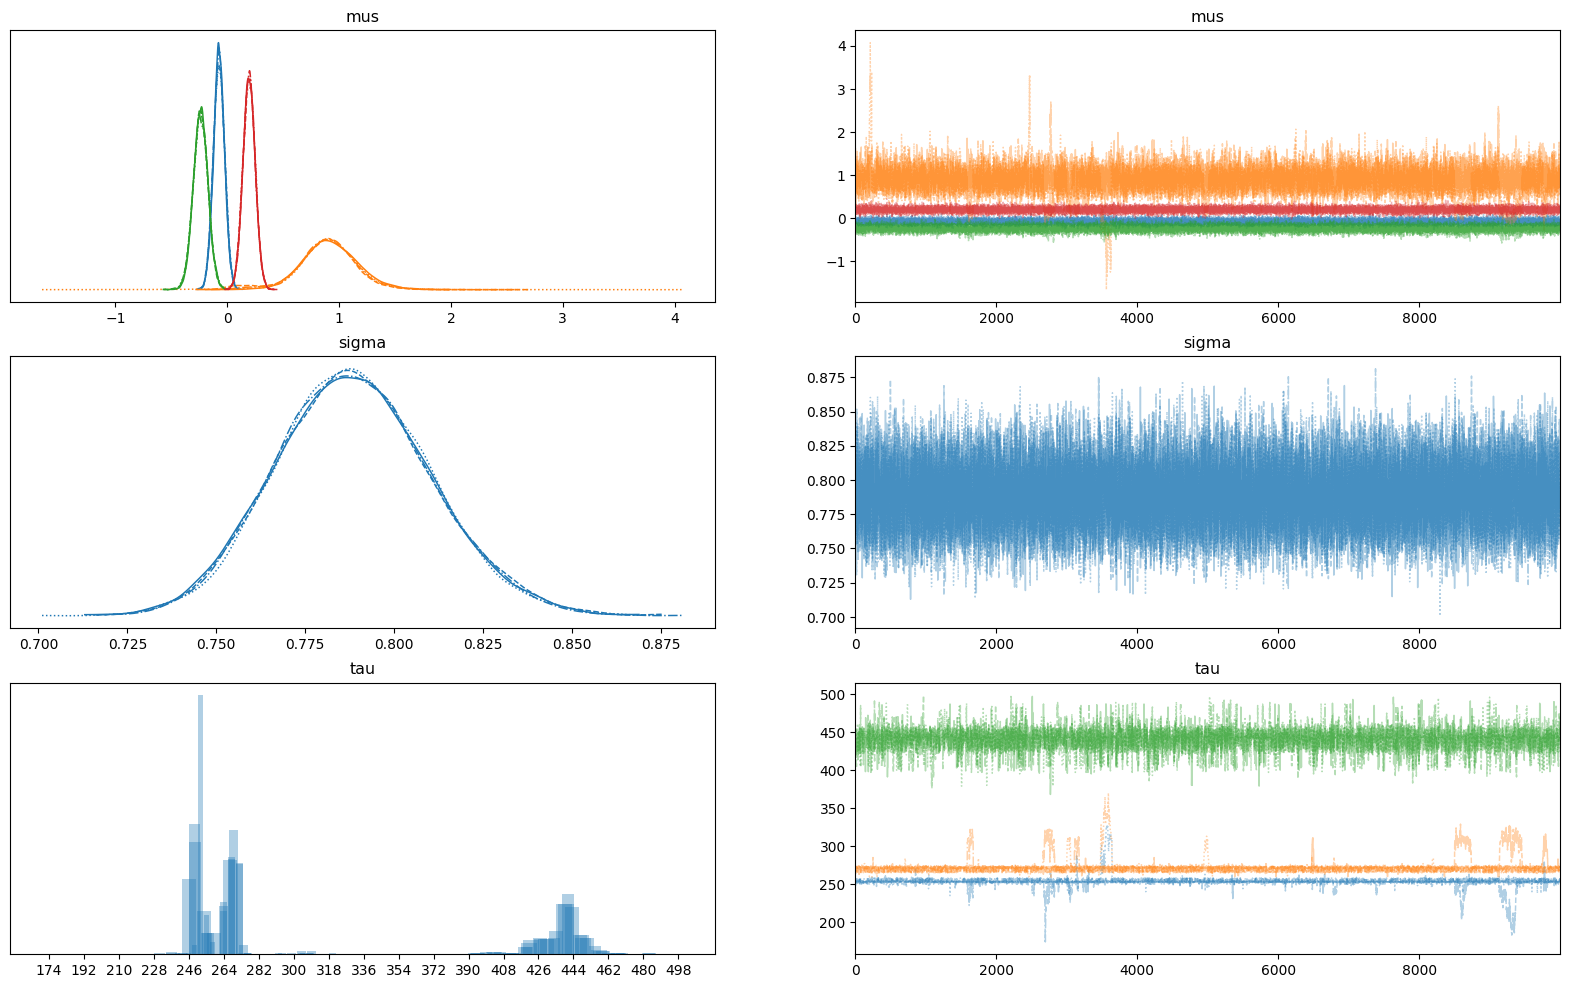

In [21]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==4

In [22]:
N_CPS = 4
data = trace[N_CPS]

In [23]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[0],0.041,0.127,-0.172,0.272,0.047,0.009,7.0,43.0,1.51
mus[1],-0.049,0.699,-1.176,1.190,0.280,0.136,7.0,25.0,1.61
mus[2],0.413,0.749,-0.579,1.550,0.257,0.058,8.0,45.0,1.41
mus[3],-0.184,0.584,-0.449,0.303,0.018,0.075,50.0,59.0,1.22
mus[4],0.196,0.060,0.098,0.307,0.004,0.004,233.0,335.0,1.01
sigma,0.787,0.023,0.743,0.830,0.003,0.001,72.0,328.0,1.05
tau[0],194.075,91.990,88.000,328.000,41.379,11.404,7.0,82.0,1.64
tau[1],279.798,37.223,251.000,340.000,17.607,10.104,5.0,19.0,2.21
tau[2],326.794,66.924,265.000,444.000,29.392,9.642,6.0,51.0,1.82
tau[3],455.006,41.750,398.000,547.000,8.563,9.516,37.0,69.0,1.08


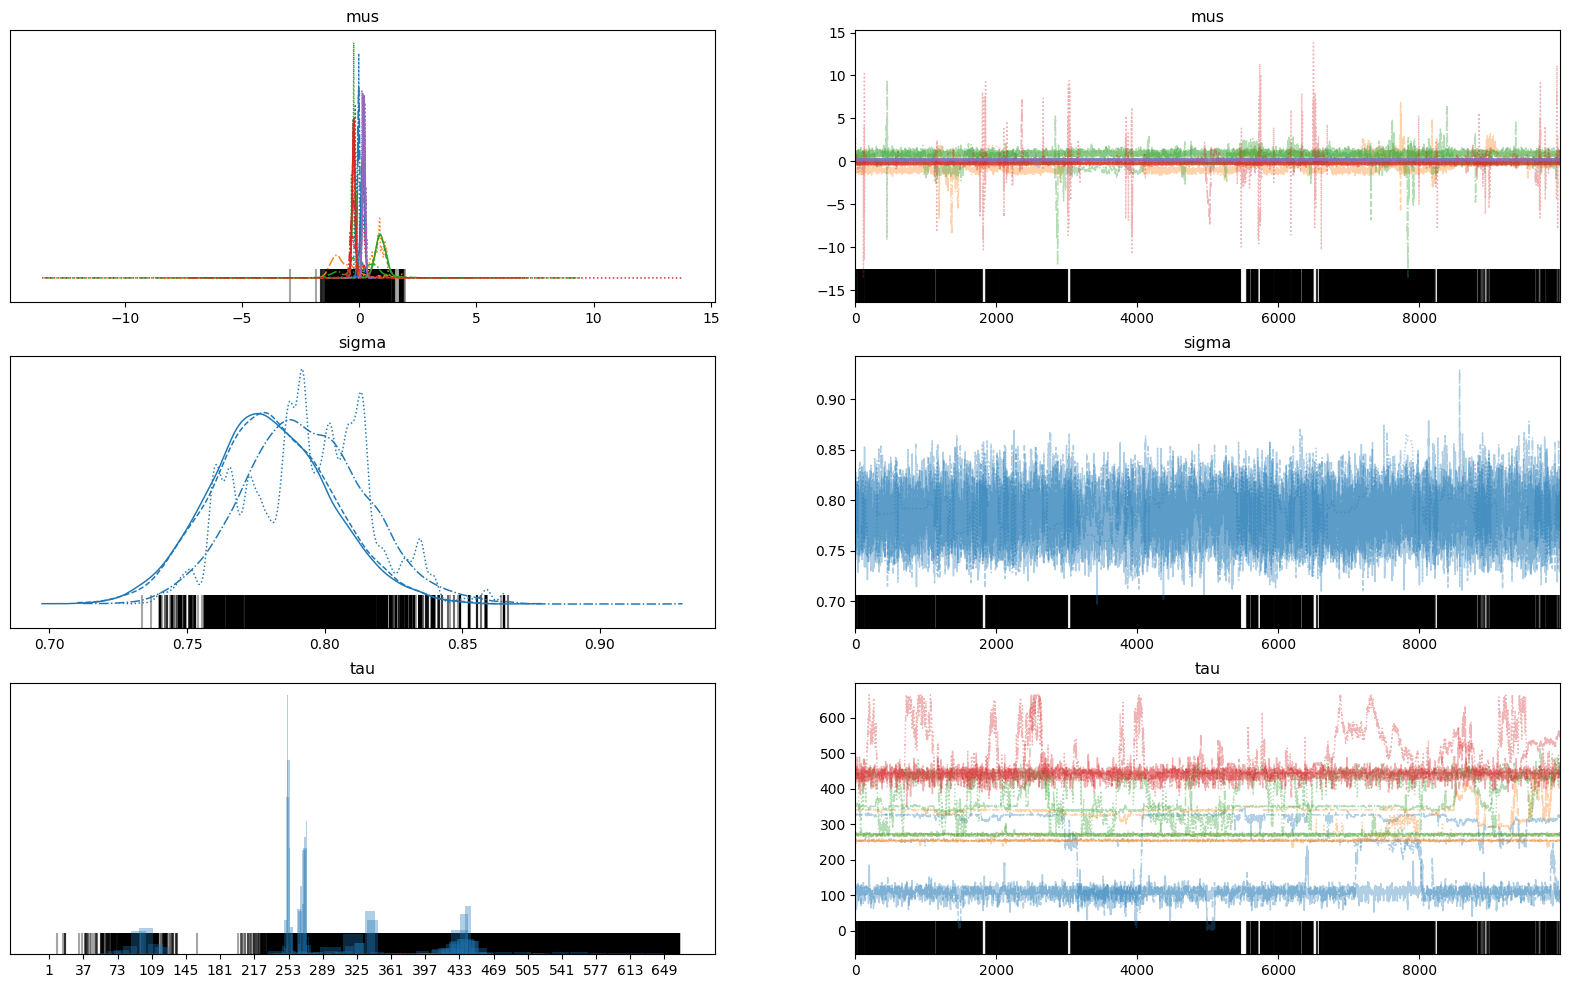

In [24]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

## N_CPS==5

In [25]:
N_CPS = 5
data = trace[N_CPS]

In [26]:
summary = az.summary(data=data)

COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[0],-0.005,0.203,-0.392,0.313,0.034,0.063,46.0,29.0,1.18
mus[1],-0.263,0.719,-1.287,0.385,0.112,0.177,13.0,51.0,1.36
mus[2],0.104,0.918,-1.361,1.406,0.132,0.110,35.0,57.0,1.23
mus[3],0.323,0.842,-1.041,1.394,0.183,0.098,15.0,148.0,1.20
mus[4],-0.234,0.242,-0.483,0.056,0.015,0.070,44.0,99.0,1.13
mus[5],0.186,0.075,0.081,0.302,0.005,0.015,120.0,128.0,1.03
sigma,0.785,0.023,0.748,0.828,0.004,0.001,31.0,160.0,1.08
tau[0],157.733,113.538,9.000,326.000,49.786,18.426,7.0,39.0,1.64
tau[1],249.192,86.689,101.000,341.000,39.242,15.462,5.0,32.0,2.07
tau[2],294.398,42.575,252.000,351.000,20.553,3.942,5.0,32.0,2.03


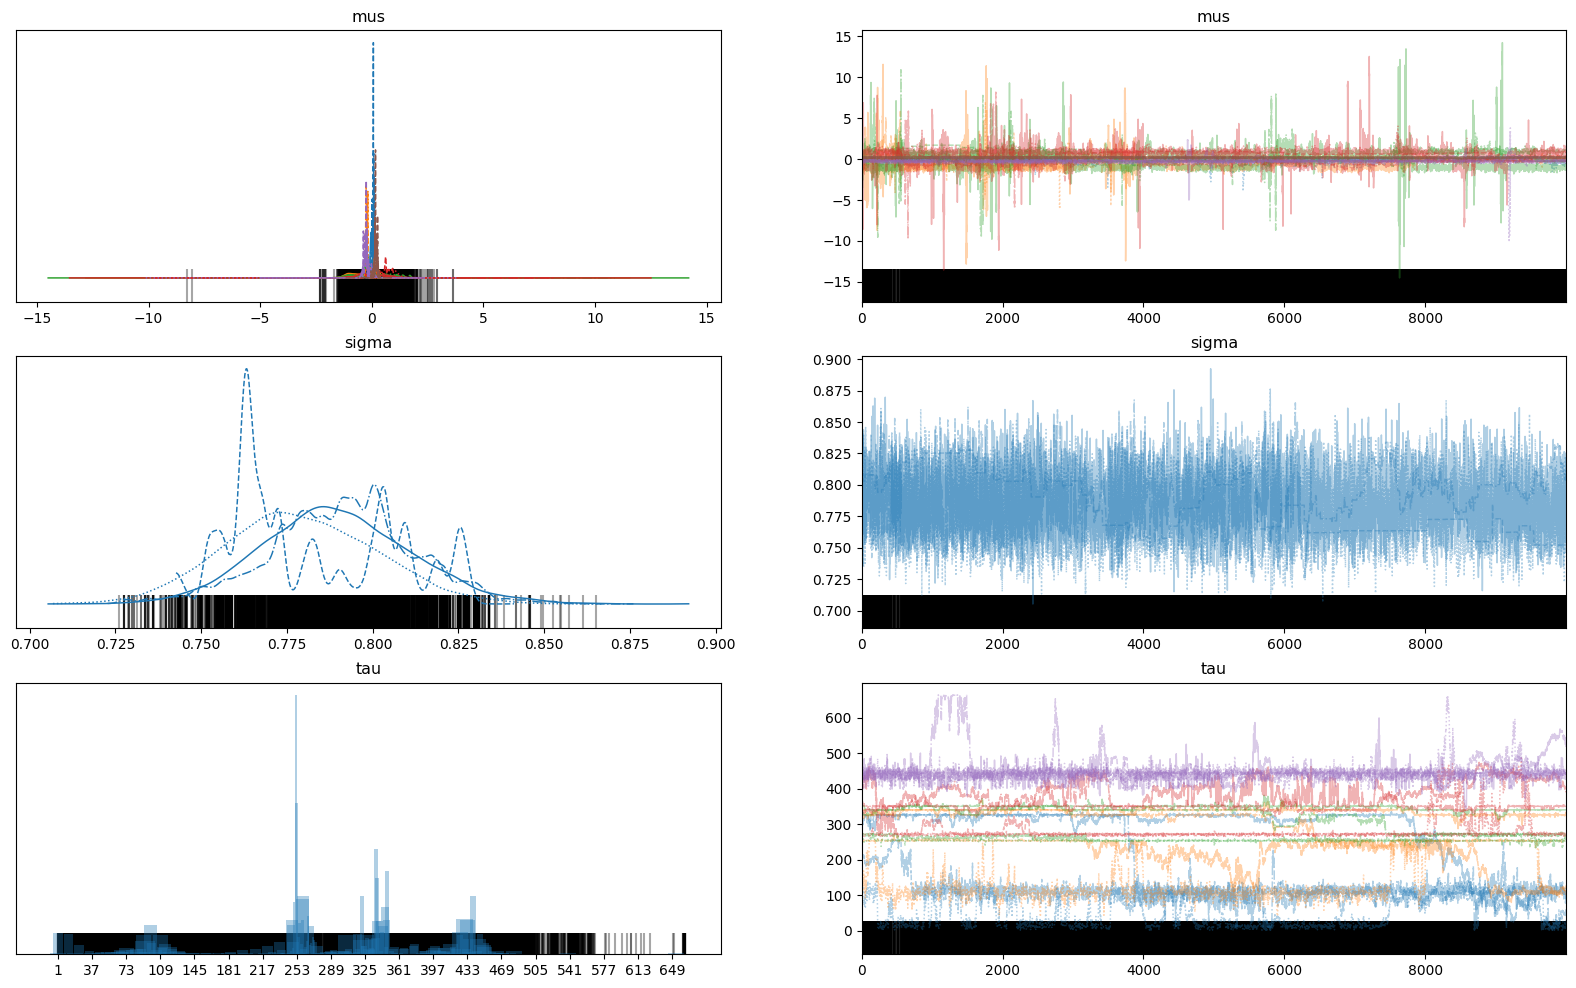

In [27]:
exclude = {"tau_raw"}

var_names = [
    name for name in data.posterior.data_vars
    if name not in exclude
]

kwargs = dict(
    data=data, 
    var_names=var_names, 
    figsize=(20,12),
)

az.plot_trace(**kwargs)
plt.show()

# ppc

In [28]:
IC = "loo"

compare_dict = {
    f"cps{k}": obj
    for k, obj in trace.items()
}

kwargs = dict(
    compare_dict=compare_dict,
    ic=IC,
)
cmp = az.compare(**kwargs)

In [29]:
cmp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
cps3,0,-794.980726,15.584288,0.000000,7.413683e-01,19.381765,0.000000,True,log
cps4,1,-799.974242,29.810845,4.993516,1.076965e-15,20.076622,3.251361,True,log
cps5,2,-800.165005,34.928336,5.184278,0.000000e+00,20.394898,4.479404,True,log
cps2,3,-803.339696,13.341996,8.358969,0.000000e+00,20.570336,6.525381,True,log
cps1,4,-803.592303,4.275330,8.611576,2.586317e-01,20.127390,6.653513,False,log


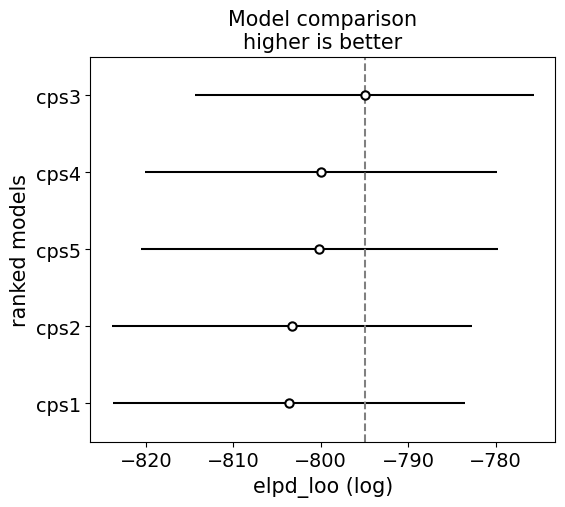

In [30]:
az.plot_compare(cmp)
plt.show()

# change point

## N_CPS==1

In [31]:
FACTOR = 3
N_CPS = 1
TRACE = trace[N_CPS]

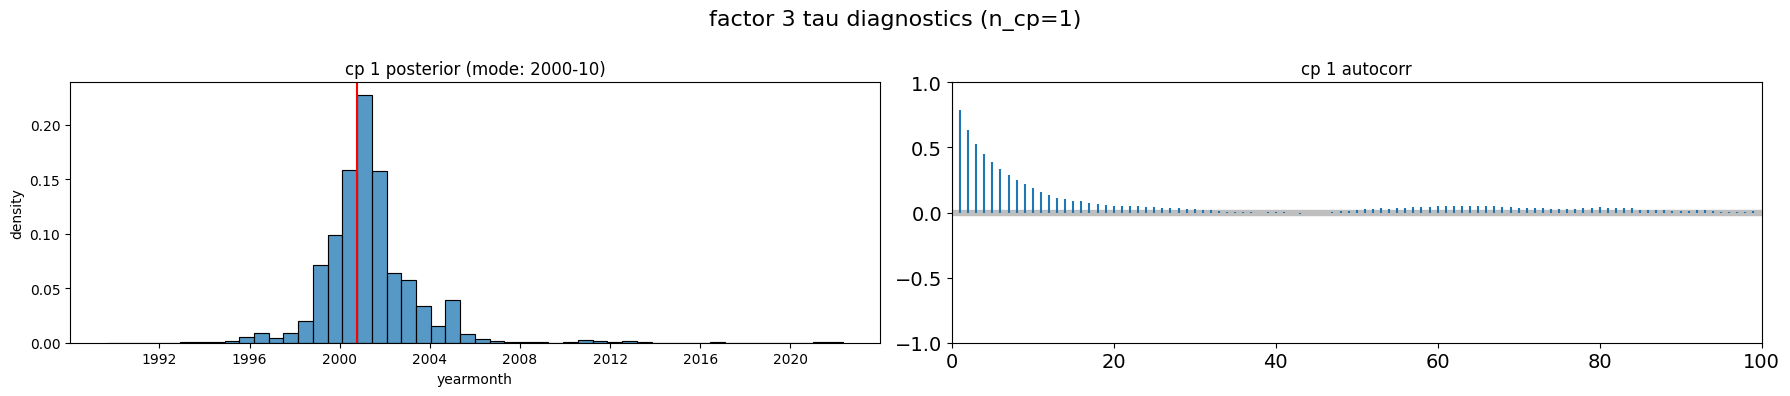

In [32]:
DATE = doc_topic_mat.index.to_timestamp()

kwargs = dict(
    trace=TRACE,
    date=DATE,
    factor=FACTOR,
)

analysis.posterior.main(**kwargs)

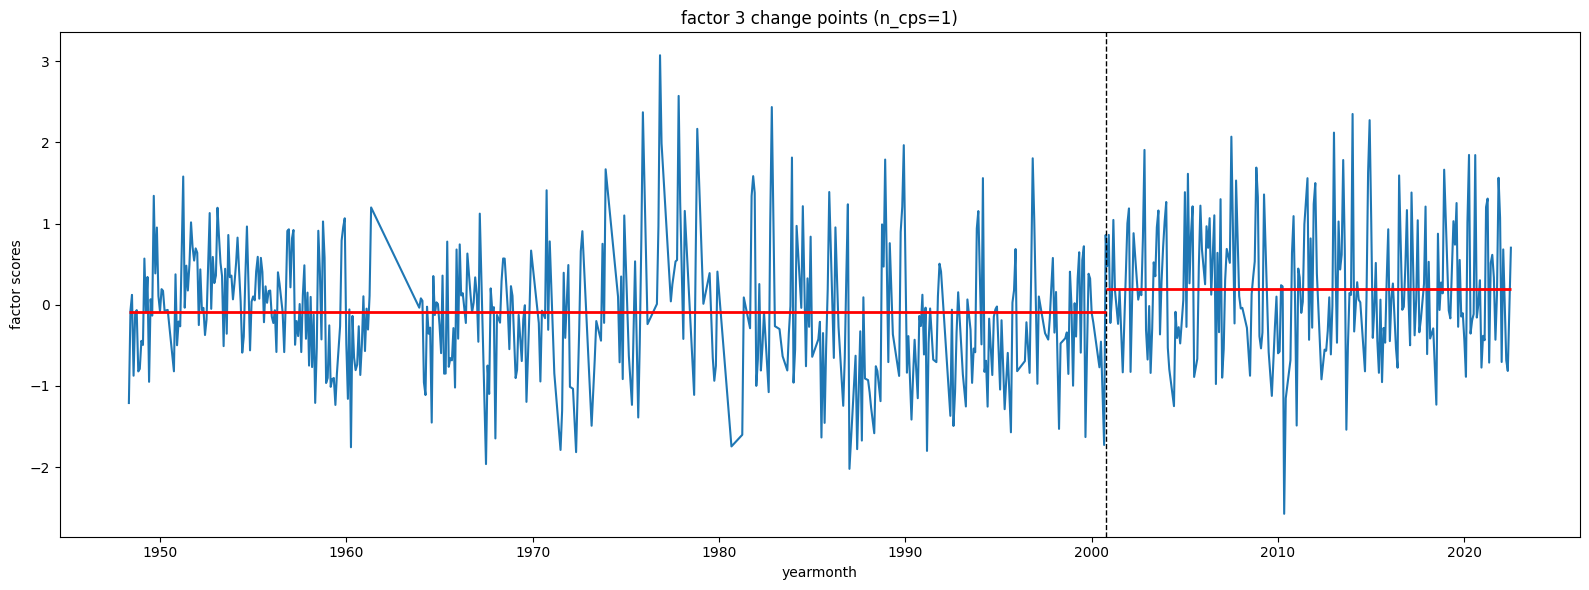

In [33]:
FIGSIZE = (16,6)

kwargs = dict(
    trace=TRACE,
    scores=scores,
    factor=FACTOR,
    figsize=FIGSIZE,
)

analysis.changepoint.main(**kwargs)

## N_CPS==3

In [35]:
FACTOR = 3
N_CPS = 3
TRACE = trace[N_CPS]

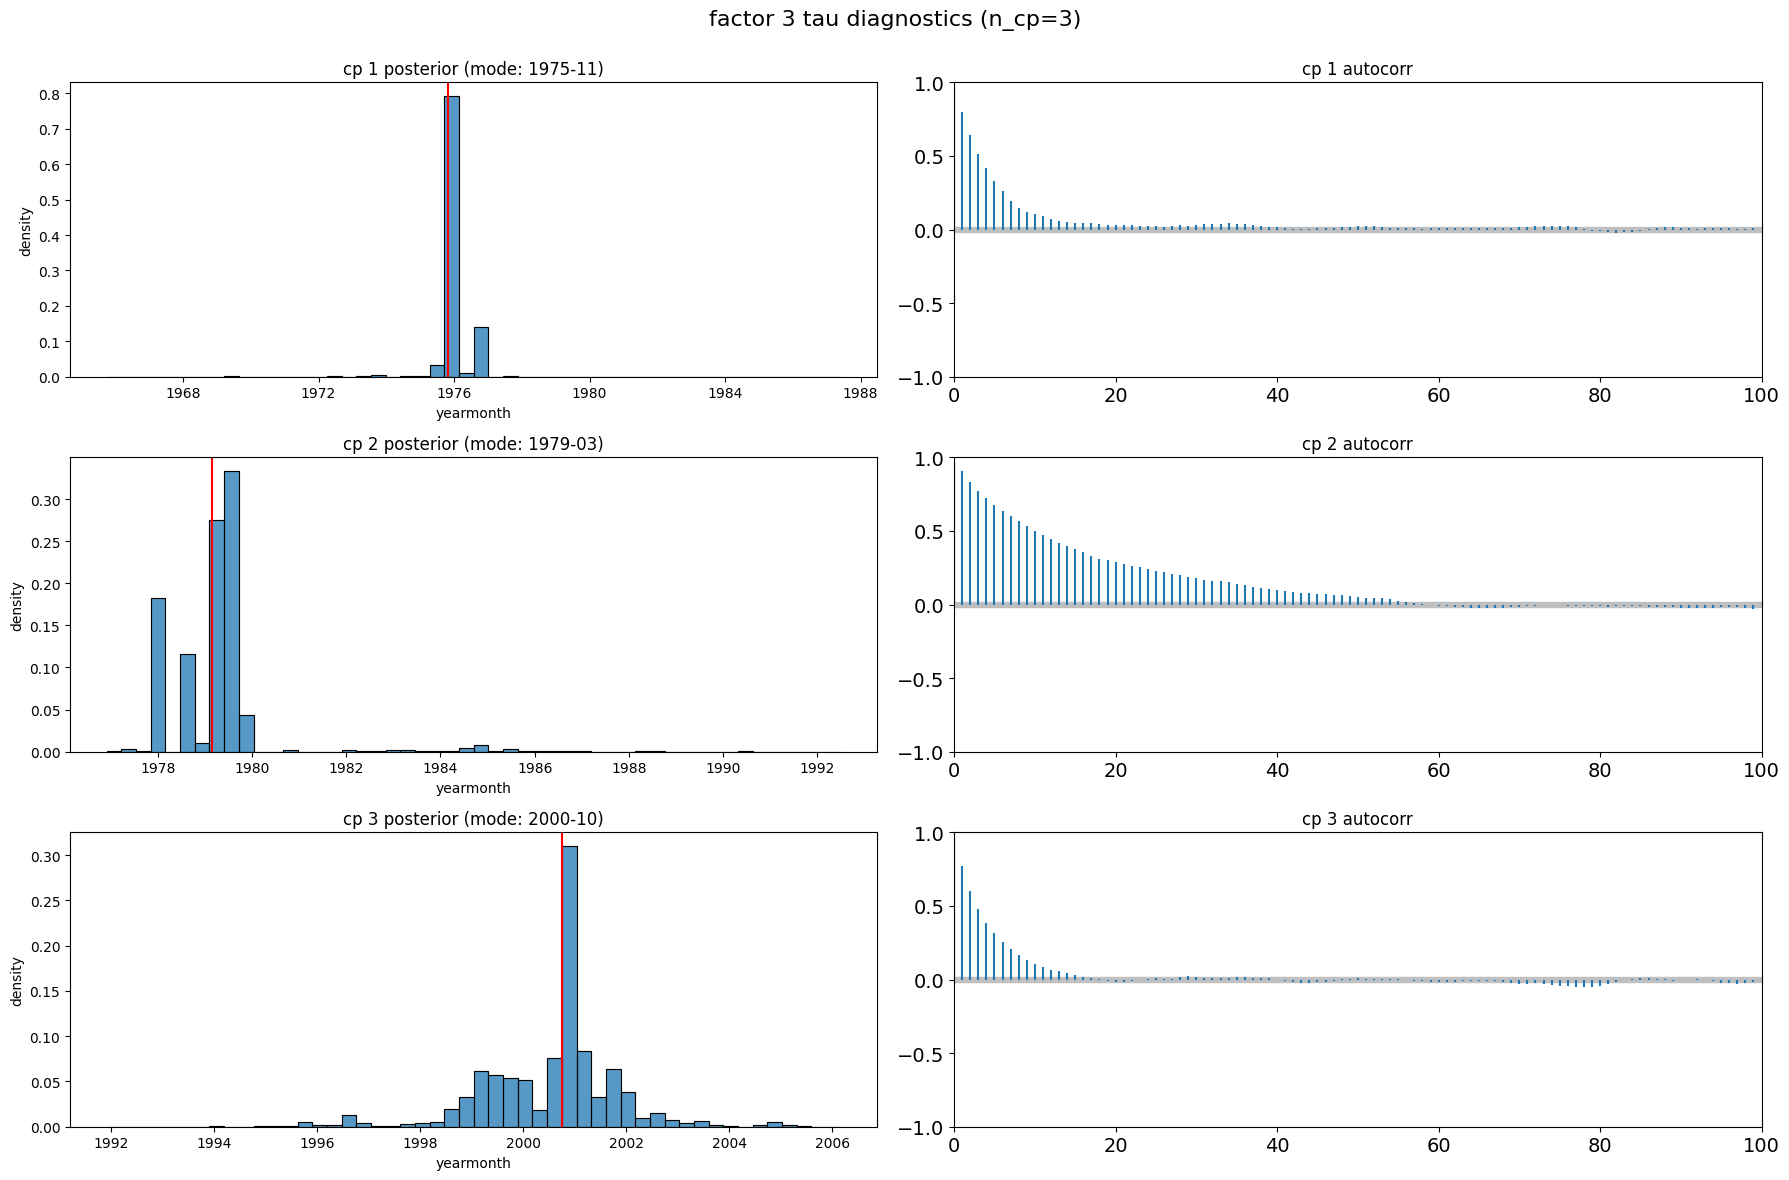

In [ ]:
DATE = scores.index.to_timestamp()

kwargs = dict(
    trace=TRACE,
    date=DATE,
    factor=FACTOR,
)

analysis.posterior.main(**kwargs)

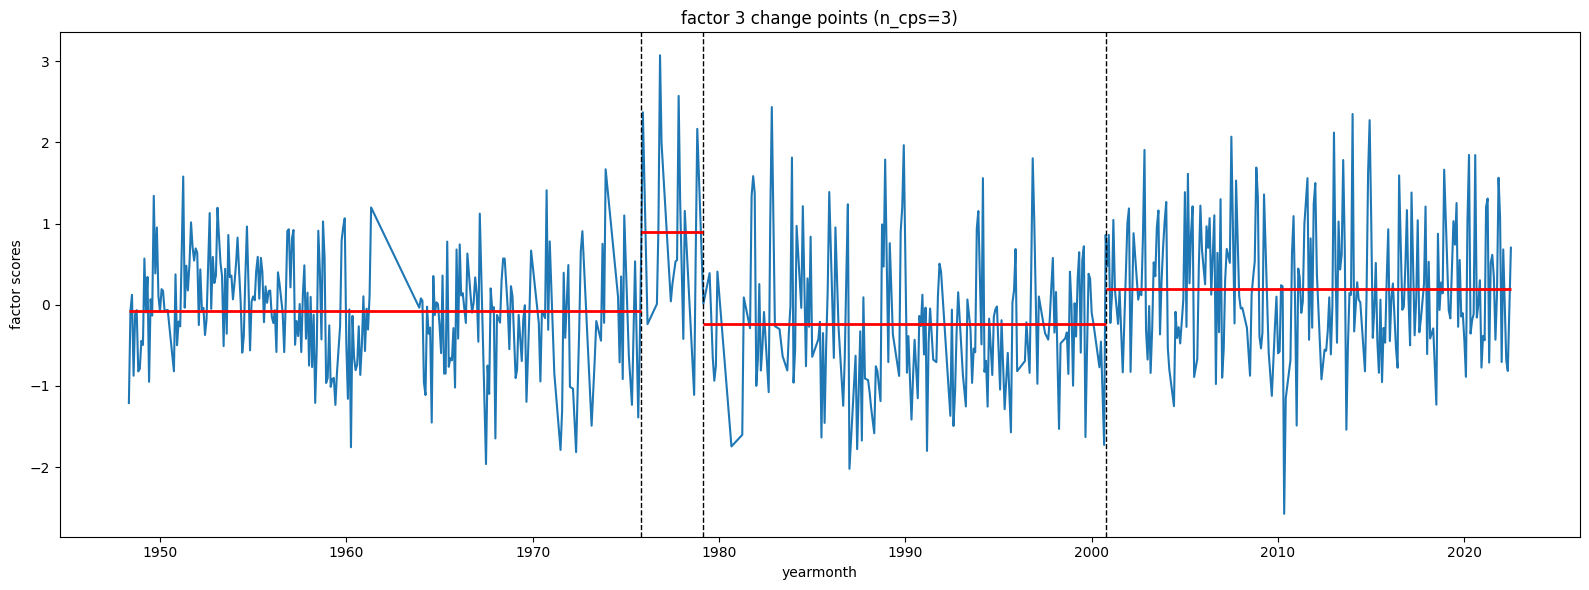

In [37]:
FIGSIZE = (16,6)

kwargs = dict(
    trace=TRACE,
    scores=scores,
    factor=FACTOR,
    figsize=FIGSIZE,
)

analysis.changepoint.main(**kwargs)